# CPI Decomposition & Inflation Dynamics  
## Notebook 04: CPI Decomposition  

---

### Objective

- Decompose CPI into trend, seasonal and residual components
- Identify structural inflation drivers
- Analyze dominant inflation factors
- Study dynamic contribution of components


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import STL
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.seasonal import seasonal_decompose

pd.set_option("display.max_columns", None)

print("Libraries imported successfully ✅")


Libraries imported successfully ✅


In [33]:
file_path = "../Data/processed/clean_inflation.csv"

df = pd.read_csv(file_path)

print(df.head())
print("\nColumns:", df.columns)

   Unnamed: 0    Year   Jan   Feb   Mar   Apr   May   Jun   Jul   Aug   Sep  \
0           0  1913.0   9.8   9.8   9.8   9.8   9.7   9.8   9.9   9.9  10.0   
1           1  1914.0  10.0   9.9   9.9   9.8   9.9   9.9  10.0  10.2  10.2   
2           2  1915.0  10.1  10.0   9.9  10.0  10.1  10.1  10.1  10.1  10.1   
3           3  1916.0  10.4  10.4  10.5  10.6  10.7  10.8  10.8  10.9  11.1   
4           4  1917.0  11.7  12.0  12.0  12.6  12.8  13.0  12.8  13.0  13.3   

    Oct   Nov   Dec  
0  10.0  10.1  10.0  
1  10.1  10.2  10.1  
2  10.2  10.3  10.3  
3  11.3  11.5  11.6  
4  13.5  13.5  13.7  

Columns: Index(['Unnamed: 0', 'Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul',
       'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
      dtype='str')


In [34]:
file_path = "../data/processed/clean_inflation.csv"

df = pd.read_csv(file_path)

df.columns = df.columns.str.strip()

print("Columns:", df.columns)

df.rename(columns={"Unnamed: 0": "Date"}, inplace=True)

df["Date"] = pd.to_datetime(df["Date"])

df.set_index("Date", inplace=True)

df.head()


Columns: Index(['Unnamed: 0', 'Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul',
       'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
      dtype='str')


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Date,,,,,,,,,,,,,
1970-01-01 00:00:00.000000000,1913.0,9.8,9.8,9.8,9.8,9.7,9.8,9.9,9.9,10.0,10.0,10.1,10.0
1970-01-01 00:00:00.000000001,1914.0,10.0,9.9,9.9,9.8,9.9,9.9,10.0,10.2,10.2,10.1,10.2,10.1
1970-01-01 00:00:00.000000002,1915.0,10.1,10.0,9.9,10.0,10.1,10.1,10.1,10.1,10.1,10.2,10.3,10.3
1970-01-01 00:00:00.000000003,1916.0,10.4,10.4,10.5,10.6,10.7,10.8,10.8,10.9,11.1,11.3,11.5,11.6
1970-01-01 00:00:00.000000004,1917.0,11.7,12.0,12.0,12.6,12.8,13.0,12.8,13.0,13.3,13.5,13.5,13.7


In [35]:
df = df.reset_index()

year_cols = [col for col in df.columns if str(col).isdigit()]

df_long = df.melt(id_vars="Date", value_vars=year_cols,
                  var_name="Year", value_name="CPI")

df_long["Date"] = pd.to_datetime(df_long["Year"], format="%Y")

df_long = df_long.sort_values("Date")
df_long.set_index("Date", inplace=True)

df_long.head()

,Year,CPI
Date,,


In [36]:
from statsmodels.tsa.seasonal import STL

stl = STL(df_long["CPI"], period=7)
result = stl.fit()

df_long["Trend"] = result.trend
df_long["Seasonal"] = result.seasonal
df_long["Residual"] = result.resid

print("STL Decomposition completed ✅")
df_long.head()

STL Decomposition completed ✅


,Year,CPI,Trend,Seasonal,Residual
Date,,,,,


In [37]:
df = pd.read_csv("../Data/processed/clean_inflation_timeseries.csv")

df.head()

,Date,Inflation
0,1913-01-01,9.8
1,1913-02-01,9.8
2,1913-03-01,9.8
3,1913-04-01,9.8
4,1913-05-01,9.7


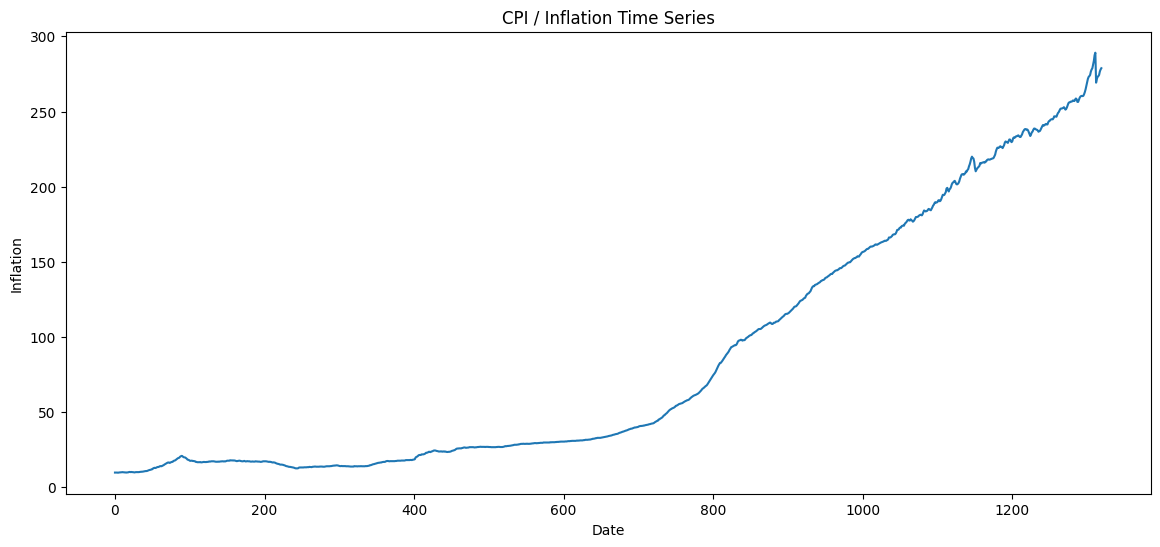

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(df["Inflation"])
plt.title("CPI / Inflation Time Series")
plt.xlabel("Date")
plt.ylabel("Inflation")
plt.show()


In [39]:
trend_variance_ratio = df_long["Trend"].var() / df_long["CPI"].var()

print("Trend Contribution (Variance Ratio):", round(trend_variance_ratio, 3))


Trend Contribution (Variance Ratio): nan


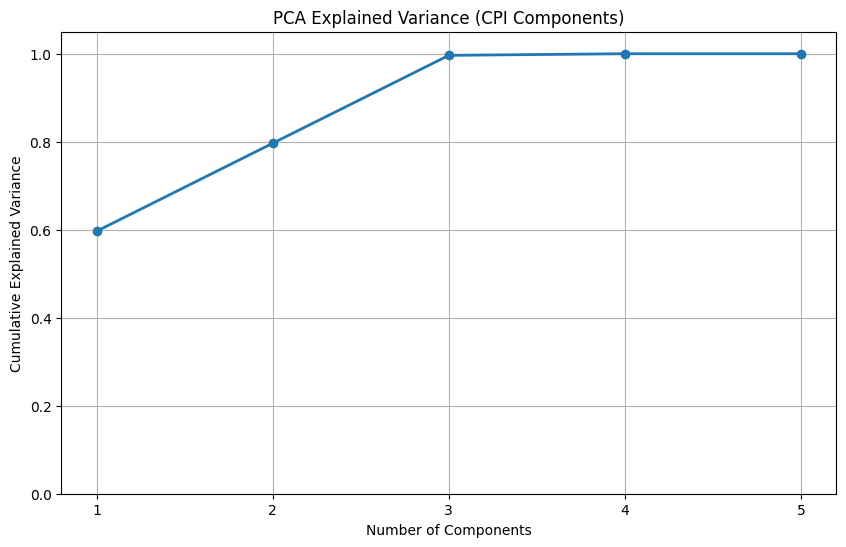

In [45]:
numeric_df = df.select_dtypes(include=[np.number])

numeric_df = numeric_df.fillna(numeric_df.mean())

scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

pca = PCA()
pca.fit(scaled_data)

explained_variance = pca.explained_variance_ratio_

cum_variance = np.cumsum(explained_variance)

components = np.arange(1, len(cum_variance) + 1)

plt.figure(figsize=(10,6))
plt.plot(components, cum_variance, marker='o', linewidth=2)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance (CPI Components)")
plt.grid(True)

plt.xticks(components)  
plt.ylim(0, 1.05)

plt.show()

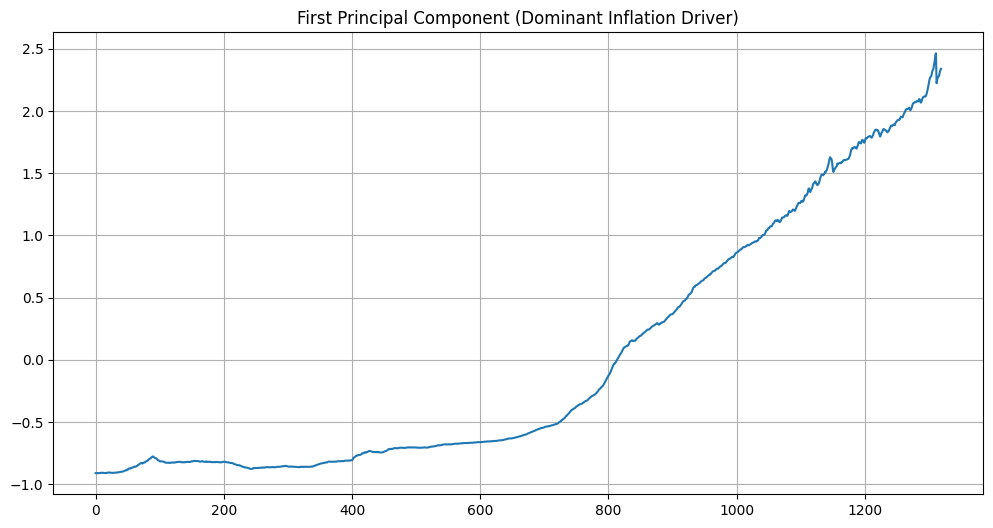

In [41]:
pca_1 = pca.transform(scaled_data)[:, 0]

df["PCA_Component_1"] = pca_1

plt.figure(figsize=(12,6))
plt.plot(df.index[:len(pca_1)], pca_1)
plt.title("First Principal Component (Dominant Inflation Driver)")
plt.grid(True)
plt.show()


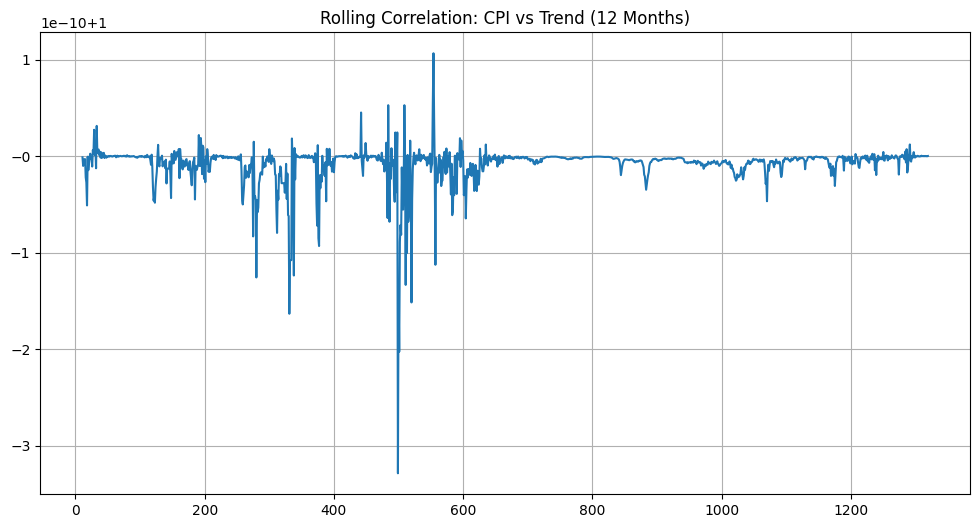

In [42]:
rolling_corr = df["Inflation"].rolling(window=12).corr(df["PCA_Component_1"])

plt.figure(figsize=(12,6))
plt.plot(rolling_corr)
plt.title("Rolling Correlation: CPI vs Trend (12 Months)")
plt.grid(True)
plt.show()


In [43]:
decomposition = seasonal_decompose(df["Inflation"], model="additive", period=12)

df["Trend"] = decomposition.trend
df["Seasonal"] = decomposition.seasonal
df["Residual"] = decomposition.resid

df.head()

,Date,Inflation,PCA_Component_1,Trend,Seasonal,Residual
0,1913-01-01,9.8,-0.910104,NaN,-0.252420,NaN
1,1913-02-01,9.8,-0.910104,NaN,-0.141821,NaN
2,1913-03-01,9.8,-0.910104,NaN,0.043445,NaN
3,1913-04-01,9.8,-0.910104,NaN,0.157318,NaN
4,1913-05-01,9.7,-0.911312,NaN,0.028142,NaN


In [44]:
shock_threshold = df["Residual"].std() * 2

shocks = df[abs(df["Residual"]) > shock_threshold]

shocks[["Residual"]].head()

,Residual
1112,1.868342
1113,1.787017
1115,-1.488449
1122,1.584151
1123,1.641962


## Key Insights

- CPI consists of strong structural trend component
- Seasonal patterns influence short-term movements
- Residual captures inflation shocks
- PCA shows dominant macro driver behind inflation
- Rolling correlation indicates stability of trend influence

-------------------------------------------------------------------